In [93]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
import tensorflow as tf
from PIL import Image
from pathlib import Path
from PIL import Image
# To save models
import json
import pickle
# from tqdm import tqdm
import warnings
import zipfile
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical   
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight




# para fijar la semilla
tf.random.set_seed(24)
def set_random_seed(seed):
    import random
    import numpy as np
    random.seed(seed)
    np.random.seed(seed)


In [94]:
seed = set_random_seed(24)
test_path = "../data/raw/archive/test"
train_path = "../data/raw/archive/train"

In [95]:
def warn (*args, **kwargs):
    pass

### Descargamos el archivo

In [96]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(150, 150),
    batch_size=8,
    class_mode="binary"
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(150, 150),
    batch_size=8,
    class_mode="binary"
)


Found 20000 images belonging to 2 classes.
Found 5000 images belonging to 2 classes.


### Mostrar las 9 primeras iamgenes

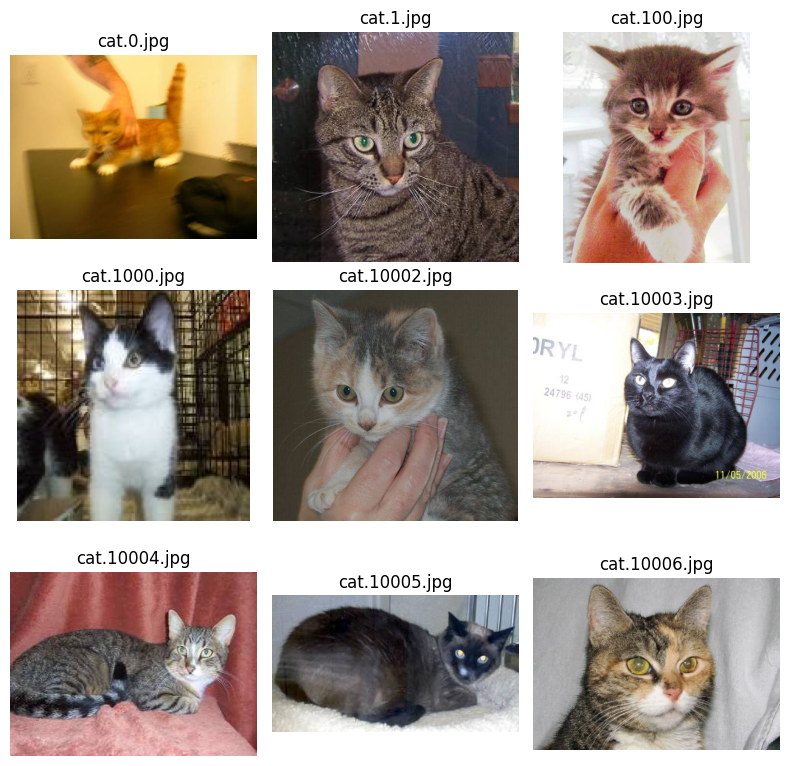

In [97]:
# Ruta de las imágenes (por ejemplo, la carpeta de entrenamiento de gatos)
train_path = Path("../data/raw/archive/train/cats")  # Cambia 'cats' a 'dogs' para ver perros

# Listar las primeras 9 imágenes
images = list(train_path.glob("*.jpg"))[:9]

plt.figure(figsize=(8,8))

for i, img_path in enumerate(images):
    img = Image.open(img_path)
    plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(img_path.name)

plt.tight_layout()
plt.show()


### Generator
> Con esto cargamos y procesamos las imagenes en lotes (batches) directamente desde el disco, mientras entreno mi modelo. Asi no necesito cargar mis imagenes en memoria, esto es ideal para datasets grandes. 

## Generacion y ajuste del modelo

In [98]:
model = Sequential()
model.add(Conv2D(input_shape=(150,150,3), filters=64, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3,3), padding="same", activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Flatten())
model.add(Dense(units=4096, activation="relu"))
model.add(Dense(units=4096, activation="relu"))
model.add(Dense(units=1, activation="sigmoid"))  #  Binario = 1 salida con sigmoid

C:\Users\camag\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [99]:

# Conjunto de datos (asegúrate de que esté organizado en subcarpetas por clase)
data_dir = "../data/raw/archive/train"

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(150, 150),
    batch_size=8,
    class_mode='binary',   # ✅ binario
    subset='training'
)

val_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(150, 150),
    batch_size=8,
    class_mode='binary',
    subset='validation'
)


Found 16000 images belonging to 2 classes.
Found 4000 images belonging to 2 classes.


### Compilar el Modelo

In [106]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', 
              loss='binary_crossentropy', 
              metrics=['accuracy'])



C:\Users\camag\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Configurar callbacks

In [ ]:


# Callback para guardar el mejor modelo
checkpoint = ModelCheckpoint(
    'mejor_modelo.h5',         # archivo donde se guarda
    monitor='val_loss',        # métrica a monitorear
    save_best_only=True,       # solo guarda si mejora
    mode='min',                # menor val_loss es mejor
    verbose=1
)

callbacks_list = [checkpoint]


In [108]:
for data_batch, label_batch in train_generator:
    print(data_batch.shape, label_batch)
    break

(8, 150, 150, 3) [1. 0. 1. 1. 1. 1. 0. 1.]


In [109]:
print(train_generator.class_indices)
print(next(train_generator)[1][:10])


{'cats': 0, 'dogs': 1}
[1. 0. 1. 1. 1. 1. 0. 1.]


In [110]:
earlystop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)



### Entrenamos

In [111]:

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

# Entrenamiento con class_weight
model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=callbacks_list,
    class_weight=class_weights
)


Epoch 1/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.6114 - loss: 0.8185

C:\Users\camag\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()



Epoch 1: val_loss improved from None to 0.55722, saving model to mejor_modelo.h5


2000/2000 ━━━━━━━━━━━━━━━━━━━━ 189s 94ms/step - accuracy: 0.6541 - loss: 0.6395 - val_accuracy: 0.7055 - val_loss: 0.5572
Epoch 2/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.7505 - loss: 0.5119
Epoch 2: val_loss did not improve from 0.55722
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 191s 96ms/step - accuracy: 0.7526 - loss: 0.5069 - val_accuracy: 0.6992 - val_loss: 0.6285
Epoch 3/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.8196 - loss: 0.3900
Epoch 3: val_loss did not improve from 0.55722
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 191s 96ms/step - accuracy: 0.8228 - loss: 0.3847 - val_accuracy: 0.7007 - val_loss: 0.6520
Epoch 4/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.8980 - loss: 0.2417
Epoch 4: val_loss did not improve from 0.55722
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 193s 97ms/step - accuracy: 0.8926 - loss: 0.2503 - val_accuracy: 0.7048 - val_loss: 0.7251
Epoch 5/10
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9510 - loss: 0.1326
Epoch 5: val_lo

In [113]:
model.save("modelo_binario_completo.h5")

